# A4: Persuasive / Deceptive Visualization
**Proposition:** *"The NYPD Civilian Complaint Review Board has become increasingly likely to hold officers accountable for misconduct."*

- **Visualization 1 (FOR — deceptive):** Cherry-picks the 2007 low (14%) and 2015 peak (35%) as anchor points; truncates the y-axis to maximize the visual jump and imply dramatic reform
- **Visualization 2 (AGAINST — earnest):** Shows the full 2005–2019 clearance rate as a nearly flat band (~65–84%), demonstrating the "improvement" is narrow and most officers are still cleared every year

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import numpy as np

DATA = 'CCRB-Complaint-Data_202007271729/allegations_202007271729.csv'
df = pd.read_csv(DATA, low_memory=False)
print(df.shape)
df.head(2)

(33358, 27)


,unique_mos_id,first_name,last_name,command_now,shield_no,complaint_id,month_received,year_received,month_closed,year_closed,...,mos_age_incident,complainant_ethnicity,complainant_gender,complainant_age_incident,fado_type,allegation,precinct,contact_reason,outcome_description,board_disposition
0,10004,Jonathan,Ruiz,078 PCT,8409,42835,7,2019,5,2020,...,32,Black,Female,38.0,Abuse of Authority,Failure to provide RTKA card,78.0,Report-domestic dispute,No arrest made or summons issued,Substantiated (Command Lvl Instructions)
1,10007,John,Sears,078 PCT,5952,24601,11,2011,8,2012,...,24,Black,Male,26.0,Discourtesy,Action,67.0,Moving violation,Moving violation summons issued,Substantiated (Charges)


In [15]:
# ── Shared prep ────────────────────────────────────────────────────────────────
df = df[df['year_received'].between(2005, 2019)].copy()

def disposition_category(d):
    if str(d).startswith('Substantiated'):
        return 'Substantiated'
    return d  # 'Unsubstantiated' or 'Exonerated'

df['disp_cat'] = df['board_disposition'].apply(disposition_category)

by_year = (
    df.groupby(['year_received', 'disp_cat'])
      .size()
      .unstack(fill_value=0)
      .reset_index()
)
by_year.columns.name = None
by_year['total'] = by_year[['Substantiated', 'Unsubstantiated', 'Exonerated']].sum(axis=1)
by_year['subst_rate'] = by_year['Substantiated'] / by_year['total'] * 100
by_year['cleared'] = by_year['Unsubstantiated'] + by_year['Exonerated']
print(by_year[['year_received','total','Substantiated','cleared','subst_rate']].to_string(index=False))

 year_received  total  Substantiated  cleared  subst_rate
          2005   1345            280     1065   20.817844
          2006   1654            323     1331   19.528416
          2007   1892            268     1624   14.164905
          2008   1631            255     1376   15.634580
          2009   1761            328     1433   18.625781
          2010   1659            290     1369   17.480410
          2011   1896            438     1458   23.101266
          2012   1841            465     1376   25.258012
          2013   2114            546     1568   25.827815
          2014   2220            618     1602   27.837838
          2015   2312            812     1500   35.121107
          2016   2345            748     1597   31.897655
          2017   2178            551     1627   25.298439
          2018   2281            647     1634   28.364752
          2019   1642            507     1135   30.876979


## Visualization 1 — FOR the proposition (deceptive)
**Framing:** Cherry-pick the 2007 outlier low and 2015 outlier peak as the story's anchors. Truncate y-axis to 10–40% so the jump looks massive. Omit the dip back down in 2017 via annotation framing.

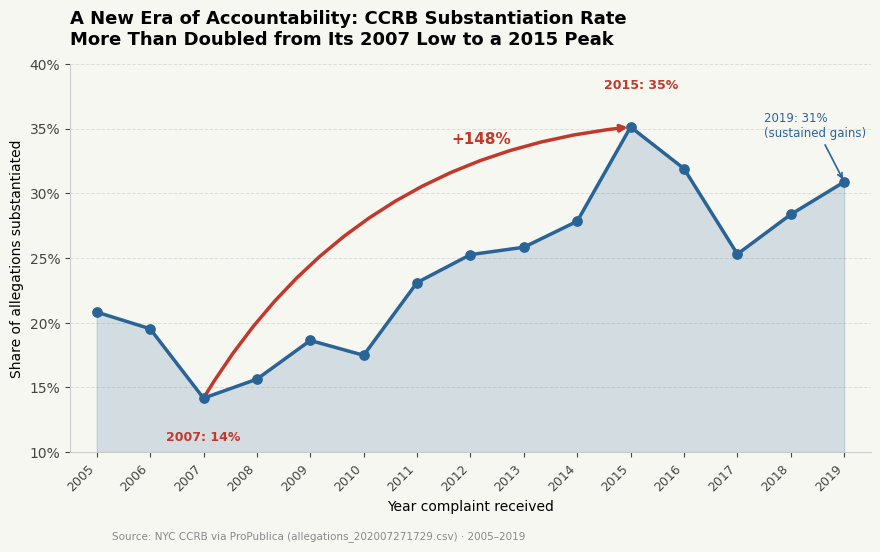

Saved viz1_for.png


In [18]:
fig, ax = plt.subplots(figsize=(9, 5.5))
fig.patch.set_facecolor('#f7f7f2')
ax.set_facecolor('#f7f7f2')

years = by_year['year_received'].values
rate  = by_year['subst_rate'].values

# ── Deceptive technique 1: truncate y-axis to 10–40% so the 14→35 jump
#    looks like it spans almost the full chart height ──────────────────
Y_MIN, Y_MAX = 10, 40

ax.fill_between(years, np.clip(rate, Y_MIN, Y_MAX), Y_MIN, alpha=0.18, color='#2a6496')
ax.plot(years, rate, color='#2a6496', linewidth=2.5, zorder=3)
ax.scatter(years, rate, color='#2a6496', s=45, zorder=4)

# ── Deceptive technique 2: draw a bold arrow from the 2007 low to 2015
#    peak, framing the whole story around those two cherrypicked outliers ─
low_idx  = list(years).index(2007)
high_idx = list(years).index(2015)
pct_growth = (rate[high_idx] - rate[low_idx]) / rate[low_idx] * 100

ax.annotate('',
            xy=(years[high_idx], rate[high_idx]),
            xytext=(years[low_idx], rate[low_idx]),
            arrowprops=dict(arrowstyle='->', color='#c0392b', lw=2.5,
                            connectionstyle='arc3,rad=-0.25'))

# Percent-growth label — offset right of arc midpoint to avoid overlap
mid_x = (years[low_idx] + years[high_idx]) / 2 + 1.2
mid_y = (rate[low_idx] + rate[high_idx]) / 2 + 9
ax.text(mid_x, mid_y,
        f'+{pct_growth:.0f}%',
        ha='center', va='bottom', fontsize=11,
        color='#c0392b', fontweight='bold')

# 2007 label directly below the dot
ax.annotate(f'2007: {rate[low_idx]:.0f}%',
            xy=(years[low_idx], rate[low_idx]),
            xytext=(years[low_idx], rate[low_idx]-2.5),
            fontsize=9, color='#c0392b', fontweight='bold', ha='center', va='top')

ax.annotate(f'2015: {rate[high_idx]:.0f}%',
            xy=(years[high_idx], rate[high_idx]),
            xytext=(years[high_idx]+0.2, rate[high_idx]+3),
            fontsize=9, color='#c0392b', fontweight='bold', ha='center')

# ── Deceptive technique 3: label 2019 endpoint positively to imply the
#    dip in 2017 is a blip, not a regression ────────────────────────────
end_idx = len(years) - 1
ax.annotate(f'2019: {rate[end_idx]:.0f}%\n(sustained gains)',
            xy=(years[end_idx], rate[end_idx]),
            xytext=(years[end_idx]-1.5, rate[end_idx]+3.5),
            arrowprops=dict(arrowstyle='->', color='#2a6496', lw=1.2),
            fontsize=8.5, color='#2a6496')

ax.set_xlim(2004.5, 2019.5)
ax.set_ylim(Y_MIN, Y_MAX)
ax.set_xticks(years)
ax.set_xticklabels(years, rotation=45, ha='right', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%d%%'))
ax.set_ylabel('Share of allegations substantiated', fontsize=10)
ax.set_xlabel('Year complaint received', fontsize=10)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.spines['left'].set_color('#ccc')
ax.spines['bottom'].set_color('#ccc')
ax.tick_params(colors='#444')
ax.yaxis.grid(True, color='#ddd', linestyle='--', linewidth=0.7)
ax.set_axisbelow(True)

ax.set_title(
    'A New Era of Accountability: CCRB Substantiation Rate\nMore Than Doubled from Its 2007 Low to a 2015 Peak',
    fontsize=13, fontweight='bold', pad=14, loc='left'
)
fig.text(0.13, 0.01,
         'Source: NYC CCRB via ProPublica (allegations_202007271729.csv) · 2005–2019',
         fontsize=7.5, color='#888')

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig('viz1_for.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved viz1_for.png')

## Visualization 2 — AGAINST the proposition (earnest)
**Framing:** The clearance rate (% of complaints that result in exoneration OR are found unsubstantiated) has stayed in a relatively narrow band — roughly 65–86% — across all 15 years. The "improvement" cherry-picked in Viz 1 is driven by two outlier years (2007 low, 2015 high); the broad picture shows the CCRB still clears the overwhelming majority of officers every year.

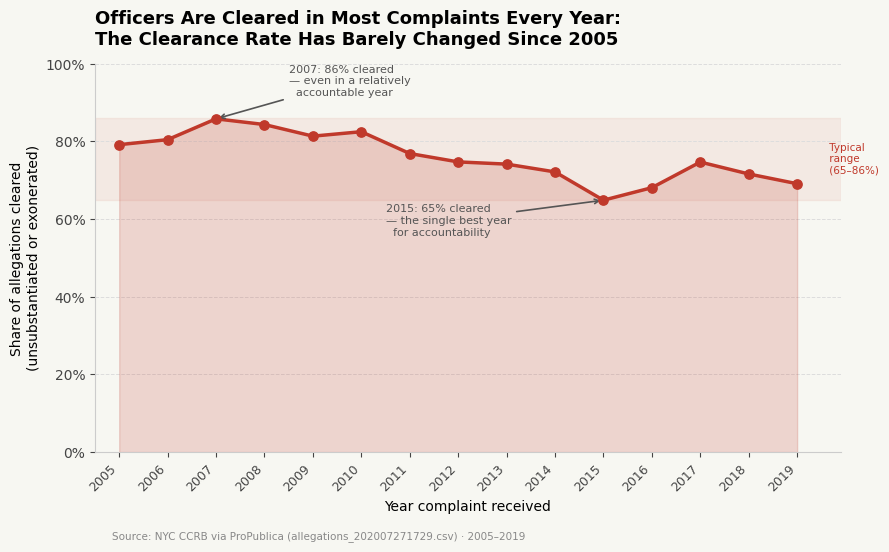

Saved viz2_against.png


In [17]:
fig, ax = plt.subplots(figsize=(9, 5.5))
fig.patch.set_facecolor('#f7f7f2')
ax.set_facecolor('#f7f7f2')

years        = by_year['year_received'].values
clearance_pct = by_year['cleared'] / by_year['total'] * 100

# ── Full y-axis 0–100 so the narrow band looks visually modest ────────────
ax.fill_between(years, clearance_pct, alpha=0.18, color='#c0392b')
ax.plot(years, clearance_pct, color='#c0392b', linewidth=2.5, zorder=3)
ax.scatter(years, clearance_pct, color='#c0392b', s=45, zorder=4)

# Annotate 2007: even the 'worst' accountability year, officers were cleared at high rates
idx_2007 = list(years).index(2007)
ax.annotate(f'2007: {clearance_pct[idx_2007]:.0f}% cleared\n— even in a relatively\n  accountable year',
            xy=(years[idx_2007], clearance_pct[idx_2007]),
            xytext=(years[idx_2007] + 1.5, clearance_pct[idx_2007] + 6),
            arrowprops=dict(arrowstyle='->', color='#555', lw=1.2),
            fontsize=8, color='#555')

# Annotate 2015: the 'best' accountability year — still nearly 2 in 3 cleared
idx_2015 = list(years).index(2015)
ax.annotate(f'2015: {clearance_pct[idx_2015]:.0f}% cleared\n— the single best year\n  for accountability',
            xy=(years[idx_2015], clearance_pct[idx_2015]),
            xytext=(years[idx_2015] - 4.5, clearance_pct[idx_2015] - 9),
            arrowprops=dict(arrowstyle='->', color='#555', lw=1.2),
            fontsize=8, color='#555')

# Shaded band to show the "typical" range
ax.axhspan(65, 86, alpha=0.07, color='#c0392b', zorder=0)
ax.text(2019.6, 75.5, ' Typical\n range\n (65–86%)', fontsize=7.5, color='#c0392b',
        va='center', ha='left')

ax.set_xlim(2004.5, 2019.9)
ax.set_ylim(0, 100)
ax.set_xticks(years)
ax.set_xticklabels(years, rotation=45, ha='right', fontsize=9)
ax.yaxis.set_major_formatter(mticker.FormatStrFormatter('%d%%'))
ax.set_ylabel('Share of allegations cleared\n(unsubstantiated or exonerated)', fontsize=10)
ax.set_xlabel('Year complaint received', fontsize=10)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)
ax.spines['left'].set_color('#ccc')
ax.spines['bottom'].set_color('#ccc')
ax.tick_params(colors='#444')
ax.yaxis.grid(True, color='#ddd', linestyle='--', linewidth=0.7)
ax.set_axisbelow(True)

ax.set_title(
    'Officers Are Cleared in Most Complaints Every Year:\nThe Clearance Rate Has Barely Changed Since 2005',
    fontsize=13, fontweight='bold', pad=14, loc='left'
)
fig.text(0.13, 0.01,
         'Source: NYC CCRB via ProPublica (allegations_202007271729.csv) · 2005–2019',
         fontsize=7.5, color='#888')

plt.tight_layout(rect=[0, 0.03, 1, 1])
plt.savefig('viz2_against.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved viz2_against.png')